# A neural Archimedean generator (ACNet)

The previous notebooks used *fixed* parametric families (Clayton, Frank).
But the generator $\varphi$ is just a completely-monotone function — so we
can **learn it** with a small neural network and fit it the same way:
`jax.grad` through the exact Bell-polynomial density.

We use an **ACNet** generator (Ling et al., 2020): a tensor-network-weighted
mixture of exponentials. Every weight is a softmax (non-negative, sums to 1)
and every rate is a positive `exp`, so the result is automatically a valid
Laplace-transform generator — $\varphi(0)=1$, completely monotone — for *any*
parameter values. No constraints to enforce during optimization.

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import numpy as np
import optax
import matplotlib.pyplot as plt

from acopula import compile_model, copula, marginal


class Uniform:
    def quantile(self, u): return u
    def cdf(self, x): return x
    def log_prob(self, x): return 0.0

## The ACNet generator

A depth-$L$ ACNet on a scalar $t$: start from a width-$w$ vector of
exponentials $e^{-s_0 t}$, then repeatedly mix (softmax weights) and multiply
by a new layer of exponentials, finally collapsing to a scalar. Here a
2-layer, width-4 net (28 parameters).

In [2]:
def init_acnet(widths, key):
    shift, lc = [], []
    for ell, w in enumerate(widths):
        key, ks, kl = jrandom.split(key, 3)
        nxt = widths[ell + 1] if ell < len(widths) - 1 else 1
        shift.append(jrandom.uniform(ks, (w,), minval=-1.0, maxval=1.0))
        lc.append(jrandom.uniform(kl, (nxt, w), minval=-1.0, maxval=1.0))
    return {"shift": tuple(shift), "lc": tuple(lc)}


def acnet_generator(shift, lc, t):
    F = jnp.exp(-jnp.exp(shift[0]) * t)                  # width-w vector
    for ell in range(1, len(shift)):
        F = jax.nn.softmax(lc[ell - 1], axis=1) @ F       # mix
        F = F * jnp.exp(-jnp.exp(shift[ell]) * t)         # new exponentials
    return (jax.nn.softmax(lc[-1], axis=1) @ F)[0]         # collapse to scalar


@copula
class ACNet:
    shift: tuple
    lc: tuple

    def generator(self, t):
        return acnet_generator(self.shift, self.lc, t)

    def generator_inv(self, u):
        # Newton solve phi(t) = u (the symbolic oryx inverse can't handle the
        # net's `squeeze`). Init from the slowest-decaying exponential.
        s_min = sum(jnp.min(jnp.exp(s)) for s in self.shift)
        u_safe = jnp.clip(u, 1e-12, 1.0 - 1e-12)
        t0 = -jnp.log(u_safe) / jnp.maximum(s_min, 1e-8)

        def step(t, _):
            psi = self.generator(t)
            dpsi = jax.grad(self.generator)(t)
            dpsi = jnp.where(jnp.abs(dpsi) < 1e-30, -1e-30, dpsi)
            return jnp.clip(t - (psi - u) / dpsi, 0.0, 1e8), None

        t_final, _ = jax.lax.scan(step, t0, xs=None, length=30)
        return t_final

## Synthetic data

Ground truth is a $d=5$ Clayton copula. We draw 1500 samples; the ACNet never
sees the Clayton form — it only sees these points.

In [3]:
@copula
class Clayton:
    theta: float
    def generator(self, t):
        return jnp.power(1.0 + t, -1.0 / self.theta)
    def generator_inv(self, u):
        return jnp.expm1(-self.theta * jnp.log(u))


d = 5
true_theta = jnp.array([3.0])

def clayton_model(theta, u):
    return Clayton(theta[0])([marginal(Uniform(), obs=u[i]) for i in range(d)])

clayton_cm = compile_model(clayton_model, template=true_theta, method="bell")
data = clayton_cm.sample(jrandom.PRNGKey(0), 1500, true_theta, method="rosenblatt")
data = jnp.clip(data, 1e-3, 1 - 1e-3)
print("data shape:", data.shape)

data shape: (1500, 5)


## Fit the neural generator

Build a flat $d=5$ copula whose generator *is* the ACNet, then maximise the
mean Bell log-likelihood with Adam — exactly the loop from the MLE notebook,
except the parameters are now neural-net weights.

In [4]:
def acnet_model(params, u):
    return ACNet(params["shift"], params["lc"])(
        [marginal(Uniform(), obs=u[i]) for i in range(d)])

params = init_acnet([4, 4], jrandom.PRNGKey(1))
acnet_cm = compile_model(acnet_model, template=params, method="bell")


def neg_mean_ll(params):
    flat = acnet_cm.flatten(params)
    return -jnp.mean(jax.vmap(lambda x: acnet_cm.ll_fn(x, flat))(data))


opt = optax.adam(0.02)
state = opt.init(params)
loss_and_grad = jax.jit(jax.value_and_grad(neg_mean_ll))

for step in range(400):
    loss, grads = loss_and_grad(params)
    updates, state = opt.update(grads, state)
    params = optax.apply_updates(params, updates)
    if step % 80 == 0:
        print(f"step {step:3d}  NLL = {float(loss):.4f}")

step   0  NLL = -0.3404


step  80  NLL = -2.0480


step 160  NLL = -2.5327


step 240  NLL = -2.7167


step 320  NLL = -2.8136


## How good is the learned copula?

Compare the mean log-likelihood of three models on the data. Independence has
mean copula log-density 0; the true Clayton is the ceiling; the neural ACNet
should land close to it — having recovered the dependence with no parametric
form assumed.

In [5]:
acnet_ll = -float(neg_mean_ll(params))
clayton_ll = float(jnp.mean(jax.vmap(
    lambda x: clayton_cm.ll_fn(x, clayton_cm.flatten(true_theta)))(data)))
print(f"independence (baseline) mean LL: {0.0:.4f}")
print(f"fitted neural ACNet     mean LL: {acnet_ll:.4f}")
print(f"true Clayton (ceiling)  mean LL: {clayton_ll:.4f}")

independence (baseline) mean LL: 0.0000
fitted neural ACNet     mean LL: 2.8591
true Clayton (ceiling)  mean LL: 3.0551


## The learned generator

An Archimedean generator is only identified **up to a scaling of its
argument**: $\varphi(t)$ and $\varphi(c\,t)$ define the *same* copula, so the
likelihood cannot pin down the scale. We therefore normalize both generators
to a common convention — $\varphi'(0) = -1$ — before comparing. After that the
learned ACNet generator closely tracks the true Clayton's; the small residual
is genuine approximation error (a finite mixture of exponentials approximating
Clayton's Gamma-frailty transform).

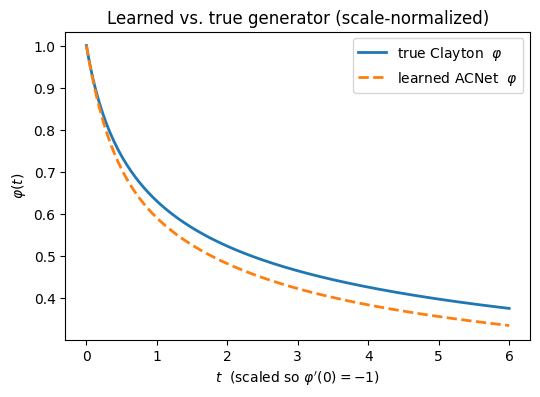

In [6]:
def normalized_phi(gen, ts):
    """Rescale t so phi'(0) = -1, removing the copula's scale ambiguity."""
    a = 1.0 / jnp.abs(jax.grad(gen)(jnp.array(0.0)))
    return jax.vmap(lambda t: gen(a * t))(ts)


clayton_gen = lambda t: jnp.power(1.0 + t, -1.0 / true_theta[0])
acnet_gen = lambda t: acnet_generator(params["shift"], params["lc"], t)

ts = jnp.linspace(0.0, 6.0, 200)
phi_clayton = normalized_phi(clayton_gen, ts)
phi_acnet = normalized_phi(acnet_gen, ts)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ts, np.asarray(phi_clayton), label="true Clayton  $\\varphi$", lw=2)
ax.plot(ts, np.asarray(phi_acnet), "--", label="learned ACNet  $\\varphi$", lw=2)
ax.set_xlabel("$t$  (scaled so $\\varphi'(0)=-1$)"); ax.set_ylabel("$\\varphi(t)$")
ax.legend(); ax.set_title("Learned vs. true generator (scale-normalized)")
plt.show()